In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import re
import os
import ast
import json
import time
import asyncio
import platform
from pathlib import Path
from typing import List, Literal, Optional
from datetime import datetime

# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 환경변수 / 진행률 / LLM 출력 스키마 관련 라이브러리
# ============================================================
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tqdm.auto import tqdm
from pydantic_ai import Agent
from pydantic_ai.models.google import GoogleModelSettings



# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

c:\Users\박정수\OneDrive\바탕 화면\spartal_python\프로젝트\최종 프로젝트\steam-indie-game-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reviews = pd.read_csv("../../../../data/preprocessed/steam_indie_reviews.csv")
df = pd.read_csv('../../../../data/preprocessed/steam_indie_genre_stratified_sample.csv')

리뷰에 장르 추가

In [3]:
genre_info = df[["appid", "primary_genre"]].drop_duplicates()

In [4]:
reviews_merged = reviews.merge(
    genre_info,
    on="appid",
    how="left"
)

In [5]:
reviews_merged['primary_genre'].value_counts()

primary_genre
RPG           51022
Sports        32900
Adventure     22020
Casual        16076
Action        15578
Strategy      14459
Simulation     9234
Racing         5096
Name: count, dtype: int64

In [6]:
reviews = reviews_merged

In [7]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,...,166325,166326,166327,166328,166329,166330,166331,166332,166333,166334,166335,166336,166337,166338,166339,166340,166341,166342,166343,166344,166345,166346,166347,166348,166349,166350,166351,166352,166353,166354,166355,166356,166357,166358,166359,166360,166361,166362,166363,166364,166365,166366,166367,166368,166369,166370,166371,166372,166373,166374,166375,166376,166377,166378,166379,166380,166381,166382,166383,166384
recommendationid,18698790,18699465,18699648,18700348,18701774,18701783,18702904,18707357,18712302,18714961,18721768,18725494,18737859,18738150,18746643,18759513,18767455,18774718,18823059,18872790,18953243,19016748,19122158,19177355,19217233,19224625,19266051,19287330,19317187,19320046,19329143,19345855,19404819,19413143,19415416,19467135,19479509,19484472,19493362,19493981,19498271,19575980,19588916,19718874,19778146,19879656,19951214,19964364,19982318,19989287,20197034,20233202,20267571,20342972,20414733,20716399,20745791,20751032,20896058,20902571,...,210066363,210080023,210257344,210316986,210772533,210832106,210883582,211097121,211742807,212672728,213844021,217619210,219665680,220757649,221298723,223787026,195773082,195780197,195828555,195828605,195897296,195900526,195901880,195904098,195909723,195913922,195951103,195977655,195988378,196072768,196093150,196094224,196109716,196137535,196140313,196561754,196561830,197027415,197283348,197386958,197434299,197476987,197523695,197547181,198904318,200098809,200171024,201170277,201184197,201386990,201425933,201447607,202724029,204448566,204532084,204593298,205146375,216117623,218587813,222468669
appid,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,...,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160
language,french,english,english,english,english,schinese,english,english,english,english,english,schinese,english,english,english,english,english,english,english,russian,russian,russian,english,english,english,english,french,english,french,english,swedish,english,english,french,french,german,english,russian,swedish,russian,polish,english,english,english,english,english,english,english,english,english,german,english,german,english,english,english,schinese,turkish,russian,english,...,russian,russian,english,english,russian,russian,russian,russian,russian,russian,russian,russian,russian,russian,russian,russian,english,english,english,english,english,english,english,english,english,english,english,english,tchinese,english,english,english,english,english,english,polish,english,english,schinese,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,spanish,english,english,english,russian,english
review,good game for this price,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...","this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. Th

In [8]:
reviews.isna().sum()

recommendationid                 0
appid                            0
language                         0
review                           0
timestamp_created                0
timestamp_updated                0
voted_up                         0
votes_up                         0
votes_funny                      0
weighted_vote_score              0
comment_count                    0
steam_purchase                   0
received_for_free                0
written_during_early_access      0
author_steamid                   0
author_num_games_owned           0
author_num_reviews               0
author_last_played               0
created_date                     0
updated_date                     0
author_last_played_date          0
playtime_forever_hours           0
playtime_last_two_weeks_hours    0
playtime_at_review_hours         2
primary_genre                    0
dtype: int64

긍정리뷰 부정리뷰 뽑기

In [7]:
reviews["sentiment"] = reviews["voted_up"].map({
    True: "positive",
    False: "negative"
})

reviews[["appid", "language", "review", "voted_up", "sentiment"]].head()

,appid,language,review,voted_up,sentiment
0,324470,french,good game for this price,True,positive
1,324470,english,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...",True,positive
2,324470,english,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",True,positive
3,324470,english,Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. This game gives you such a r...,True,positive
4,324470,english,It's Lit,True,positive


In [10]:
#나라별 리뷰수 카운트 하기

일단 영어리뷰만 뽑기

In [11]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,...,166325,166326,166327,166328,166329,166330,166331,166332,166333,166334,166335,166336,166337,166338,166339,166340,166341,166342,166343,166344,166345,166346,166347,166348,166349,166350,166351,166352,166353,166354,166355,166356,166357,166358,166359,166360,166361,166362,166363,166364,166365,166366,166367,166368,166369,166370,166371,166372,166373,166374,166375,166376,166377,166378,166379,166380,166381,166382,166383,166384
recommendationid,18698790,18699465,18699648,18700348,18701774,18701783,18702904,18707357,18712302,18714961,18721768,18725494,18737859,18738150,18746643,18759513,18767455,18774718,18823059,18872790,18953243,19016748,19122158,19177355,19217233,19224625,19266051,19287330,19317187,19320046,19329143,19345855,19404819,19413143,19415416,19467135,19479509,19484472,19493362,19493981,19498271,19575980,19588916,19718874,19778146,19879656,19951214,19964364,19982318,19989287,20197034,20233202,20267571,20342972,20414733,20716399,20745791,20751032,20896058,20902571,...,210066363,210080023,210257344,210316986,210772533,210832106,210883582,211097121,211742807,212672728,213844021,217619210,219665680,220757649,221298723,223787026,195773082,195780197,195828555,195828605,195897296,195900526,195901880,195904098,195909723,195913922,195951103,195977655,195988378,196072768,196093150,196094224,196109716,196137535,196140313,196561754,196561830,197027415,197283348,197386958,197434299,197476987,197523695,197547181,198904318,200098809,200171024,201170277,201184197,201386990,201425933,201447607,202724029,204448566,204532084,204593298,205146375,216117623,218587813,222468669
appid,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,...,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160
language,french,english,english,english,english,schinese,english,english,english,english,english,schinese,english,english,english,english,english,english,english,russian,russian,russian,english,english,english,english,french,english,french,english,swedish,english,english,french,french,german,english,russian,swedish,russian,polish,english,english,english,english,english,english,english,english,english,german,english,german,english,english,english,schinese,turkish,russian,english,...,russian,russian,english,english,russian,russian,russian,russian,russian,russian,russian,russian,russian,russian,russian,russian,english,english,english,english,english,english,english,english,english,english,english,english,tchinese,english,english,english,english,english,english,polish,english,english,schinese,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,spanish,english,english,english,russian,english
review,good game for this price,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...","this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. Th

In [8]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

reviews_en.shape

(72268, 26)

긍정리뷰 부정리뷰 샘플 추출

In [9]:
positive_sample = reviews_en[reviews_en["voted_up"] == True].sample(
    20,
    random_state=42
)

negative_sample = reviews_en[reviews_en["voted_up"] == False].sample(
    20,
    random_state=42
)

review_sample = pd.concat([positive_sample, negative_sample])

review_sample[["sentiment", "review"]].head()

,sentiment,review
15895,positive,A fun golf game to play around with your friends. Nothing more special than that. Try it out!
100077,positive,A Great Start for Non-Horror Fans and a Solid Experience for Horror Lovers\r\n\r\nThis game is a perfect entry point...
120950,positive,i really would love to see more story within the universe. perhaps a genre shift into competing with a certain devel...
76772,positive,"This game needs a better, more clear upgrade tree."
111545,positive,"I played the demo religiously before the full release, and let me just say that the full game is even better than th..."


In [10]:
reviews.groupby("voted_up")["playtime_forever_hours"].median()

#True는 긍정
#False는 부정

voted_up
False     4.800000
True     11.566667
Name: playtime_forever_hours, dtype: float64

긍정리뷰를 남긴 사람이 전반적으로 플레이 타임이 길었다

심층분석

필요한 컬럼만 추출

In [11]:
reviews[[
    "appid",
    "language",
    "review",
    "sentiment",
    "playtime_forever_hours",
    "timestamp_created",
    "primary_genre"
]].head()

,appid,language,review,sentiment,playtime_forever_hours,timestamp_created,primary_genre
0,324470,french,good game for this price,positive,3.483333,1445883033,Racing
1,324470,english,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...",positive,0.216667,1445885616,Racing
2,324470,english,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",positive,13.616667,1445886217,Racing
3,324470,english,Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. This game gives you such a r...,positive,7.483333,1445889159,Racing
4,324470,english,It's Lit,positive,8.666667,1445895144,Racing


긍정과 부정의 비율 보기

In [12]:
sentiment_ratio = reviews["sentiment"].value_counts(normalize=True) * 100
sentiment_ratio.round(2)

sentiment
positive    91.93
negative     8.07
Name: proportion, dtype: float64

전체적으로 긍정의 리뷰 비율이 높음

리뷰의 길이

In [13]:
reviews["review_length"] = reviews["review"].astype(str).str.len()

reviews[["review", "sentiment", "review_length"]].head()

,review,sentiment,review_length
0,good game for this price,positive,24
1,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...",positive,119
2,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",positive,387
3,Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. This game gives you such a r...,positive,1100
4,It's Lit,positive,8


긍정과 부정의 리뷰의 길이를 봐보자

In [14]:
length_summery = (
    reviews.groupby('sentiment')['review_length']
    .describe()
)
length_summery

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,13421.0,353.073169,726.584328,1.0,33.0,110.0,343.0,8000.0
positive,152964.0,171.034753,428.265546,1.0,13.0,45.0,148.0,8000.0


대체적으로 부정리뷰의 길이가 더 긴것을 확인할 수있음

중앙값으로 봐보면

In [15]:
reviews.groupby('sentiment')['review_length'].median()

sentiment
negative    110.0
positive     45.0
Name: review_length, dtype: float64

** 즉 부정적인 리뷰를 남긴 유저가 좀더 자세한 리뷰를 남겻을 가능성을 보임

리뷰 길이 시각화

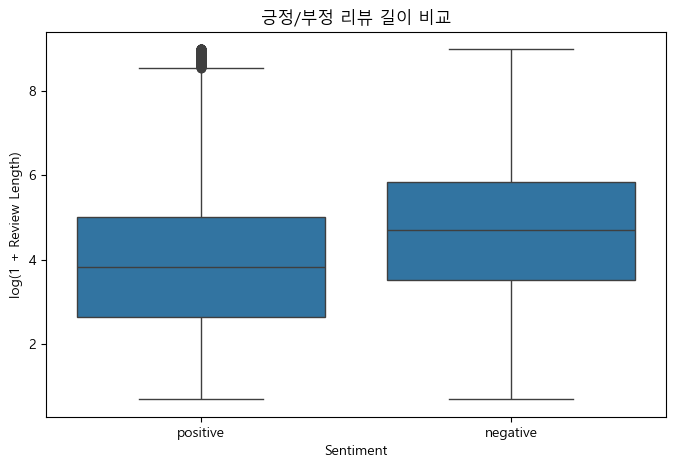

In [16]:
reviews["log_review_length"] = np.log1p(reviews["review_length"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_review_length"
)

plt.title("긍정/부정 리뷰 길이 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Review Length)")
plt.show()

플레이 타임을 전처리

In [17]:
reviews["playtime_hours"] = (reviews["playtime_forever_hours"] / 60).round(2)

reviews[["playtime_forever_hours", "playtime_hours"]].head()

,playtime_forever_hours,playtime_hours
0,3.483333,0.06
1,0.216667,0.00
2,13.616667,0.23
3,7.483333,0.12
4,8.666667,0.14


긍정과 부정별 플레이타임 비교

In [18]:
playtime_summary = (
    reviews.groupby("sentiment")["playtime_hours"]
    .describe()
)

playtime_summary

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,13421.0,0.319460,1.155147,0.0,0.02,0.08,0.24,45.04
positive,152964.0,0.519298,2.702912,0.0,0.10,0.19,0.41,505.75


중앙값만 보기

In [19]:
reviews.groupby("sentiment")["playtime_hours"].median()

sentiment
negative    0.08
positive    0.19
Name: playtime_hours, dtype: float64

플레이 타임의 극단값이 너무 커서 로그변환 진행 후 시각화

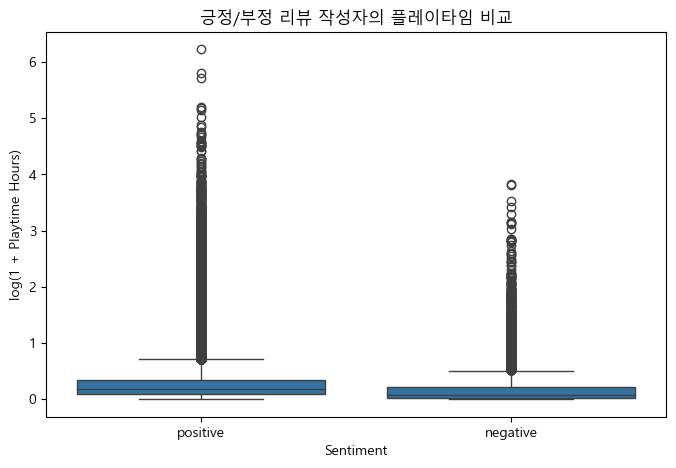

In [21]:
reviews["log_playtime_hours"] = np.log1p(reviews["playtime_hours"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_playtime_hours"
)

plt.title("긍정/부정 리뷰 작성자의 플레이타임 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Playtime Hours)")
plt.show()

언어의 분포 확인

In [22]:
language_summary = (
    reviews["language"]
    .value_counts()
    .reset_index()
)

language_summary.columns = ["language", "review_count"]
language_summary.head(20)

,language,review_count
0,english,72268
1,schinese,38644
2,russian,15898
3,spanish,9269
4,german,5762
5,brazilian,4167
6,french,4056
7,japanese,2756
8,tchinese,2643
9,koreana,2548


시각화

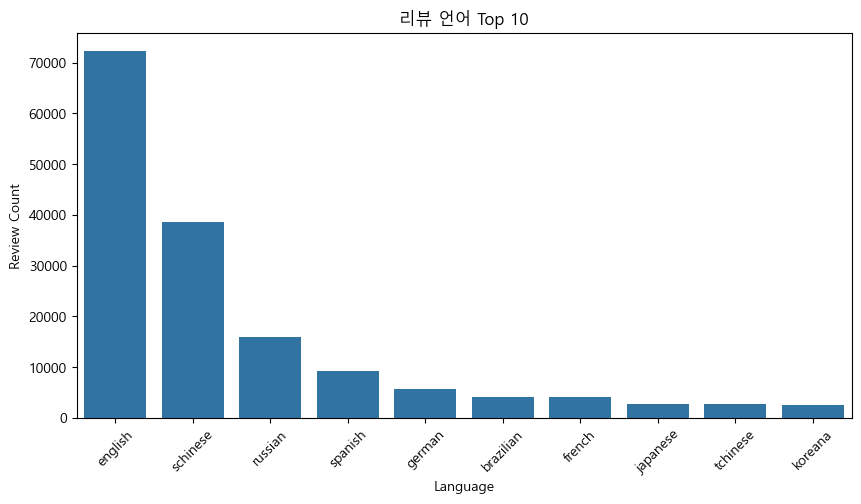

In [23]:
top_lang = reviews["language"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_lang.index,
    y=top_lang.values
)

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

언어별 긍정율 비율

In [24]:
lang_sentiment = (
    reviews.groupby("language")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .sort_values("review_count", ascending=False)
)

lang_sentiment.head(20)

,review_count,positive_ratio
language,,
english,72268,0.921597
schinese,38644,0.910956
russian,15898,0.914014
spanish,9269,0.951451
german,5762,0.919299
brazilian,4167,0.961123
french,4056,0.933679
japanese,2756,0.826923
tchinese,2643,0.894816


언어는 너무다양하기때문에 50개이상의 리뷰가 있는 리뷰만봐보자

In [25]:
lang_sentiment_50 = lang_sentiment[
    lang_sentiment["review_count"] >= 50
].copy()

lang_sentiment_50 = lang_sentiment_50.sort_values("positive_ratio", ascending=False)

시각화

리뷰 언어별 긍정율

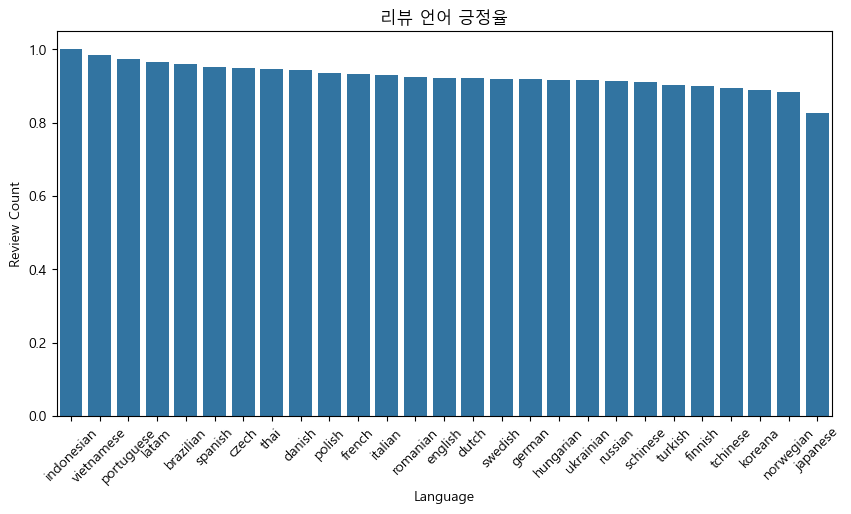

In [26]:
pos_ratio = lang_sentiment_50

plt.figure(figsize=(10, 5))
sns.barplot(data = pos_ratio , x = 'language',y = 'positive_ratio')

plt.title("리뷰 언어 긍정율")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

시간칼럼 변화

In [27]:
reviews["created_date"] = pd.to_datetime(
    reviews["timestamp_created"],
    unit="s",
    errors="coerce"
)

reviews["created_month"] = reviews["created_date"].dt.to_period("M").astype(str)

reviews[["timestamp_created", "created_date", "created_month"]].head()

,timestamp_created,created_date,created_month
0,1445883033,2015-10-26 18:10:33,2015-10
1,1445885616,2015-10-26 18:53:36,2015-10
2,1445886217,2015-10-26 19:03:37,2015-10
3,1445889159,2015-10-26 19:52:39,2015-10
4,1445895144,2015-10-26 21:32:24,2015-10


In [31]:
monthly_review = (
    reviews.groupby("created_month")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .reset_index()
)

monthly_review.head()

,created_month,review_count,positive_ratio
0,2015-10,18,0.888889
1,2015-11,14,1.000000
2,2015-12,18,0.833333
3,2016-01,8,0.500000
4,2016-02,8,0.750000


전체 리뷰 중 긍정 리뷰 비율은 약 91.93%로 나타났다.
부정 리뷰는 긍정 리뷰보다 리뷰 길이 중앙값이 길었고, 이는 불만 유저가 더 구체적인 문제를 작성했을 가능성을 보여준다.
플레이타임 기준으로는 긍정 리뷰 작성자의 중앙 플레이타임이 더 높았다.
언어별로는 영어 리뷰가 가장 많았으며, 리뷰 수 50개 이상 언어 중 인도네시아 언어의 긍정 비율이 가장 높았다.

## 긍정리뷰와 부정리뷰 키워드 분석

영어로 작성된 리뷰로 먼저 확인작업 진행

전처리

In [32]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

reviews_en["clean_review"] = reviews_en["review"].apply(clean_text)

reviews_en[["review", "clean_review"]].head()

,review,clean_review
1,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...",bgm good graphics good but slip effect is too excessive so level of difficulty is too hard for beginner to play
2,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",this game is like a zen garden i love it pros it s very relaxing good controls awesome leveldesign relaxing music co...
3,Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. This game gives you such a r...,ever played bhop surf if so this games mechanics will feel instantly similar too you this game gives you such a rush...
4,It's Lit,it s lit
6,"Greatness comes in all sorts of things, but this game totally has what it takes to get there. At the moment it has e...",greatness comes in all sorts of things but this game totally has what it takes to get there at the moment it has eve...


불용어 제거후 단어 빈도 확인

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

stop_words = [
    # 기본 영어
    "the","and","is","it","to","of","a","in","for","this","that","you",
    "with","on","as","are","was","but","be","have","not","so","if","at",
    "by","an","or","from","they","we","he","she","them","his","her","our",
    "their","its","who","what","which","when","where","why","how",

    # 대명사/지시어
    "i","me","my","mine","your","yours","our","ours","their","theirs",
    "him","herself","himself","ourselves","themselves",

    # 일반 동사 (의미 약함)
    "get","got","make","made","go","went","take","took","use","used",
    "try","tried","give","gave","come","came","want","wanted",
    "see","seen","look","looked","find","found","think","thought",
    "know","knew","keep","kept","put","set","run","ran",

    # 시간/수량
    "one","two","three","first","second","many","much","lot","lots",
    "few","some","any","every","each","all",
    "time","times","hour","hours","day","days","week","weeks","month","months",

    # 게임 리뷰 흔한 단어
    "game","games","play","playing","played","player","players",
    "thing","things","way","something","anything","everything",
    "stuff","part","parts","experience",

    # 평가 표현 (너무 일반적)
    "good","bad","great","nice","fun","boring","awesome","amazing",
    "love","like","liked","hate","dislike","recommend","recommended",
    "best","worst","better","worse","cool","enjoy","enjoyed",

    # 강도/정도 표현
    "really","very","pretty","quite","too","so","just","even","still",
    "well","almost","maybe","probably","definitely","actually",

    # 부정/축약형
    "im","ive","dont","didnt","cant","couldnt","would","should",
    "wasnt","werent","isnt","arent","doesnt","hadnt","hasnt","havent",

    # 기타 잡단어
    "yes","no","ok","okay","uh","um",
    "etc","etc.","lol","haha","yeah","yep",

    # 리뷰에서 흔히 나오는 무의미 단어
    "edit","update","review","reviews","steam","pc","version","patch",
    "dev","developer","devs","support","thanks",

    # 숫자/단위 관련
    "10","20","30","100","1000",
    "fps","gb","mb"
]
    

def get_top_words(data, sentiment_value, n=30):
    text_data = data[data["sentiment"] == sentiment_value]["clean_review"]
    
    vectorizer = CountVectorizer(
        stop_words=stop_words,
        min_df=3
    )
    
    word_matrix = vectorizer.fit_transform(text_data)
    
    word_counts = word_matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()
    
    result = pd.DataFrame({
        "word": words,
        "count": word_counts
    }).sort_values("count", ascending=False)
    
    return result.head(n)

positive_words = get_top_words(reviews_en, "positive", 30)
negative_words = get_top_words(reviews_en, "negative", 30)

positive_words

,word,count
1903,can,14482
9003,more,13236
14307,there,10782
9771,out,7472
13576,story,6487
6466,has,6371
15169,up,6307
4047,do,5990
411,also,5985
15762,will,5975


불용어를 아무리 추가해도 노이즈 자꾸 나옴 
방식변경 => TF-IDF방식
많이나오는 단어는 중요할 수 있어 가산점을 주지만 모든 곳에서 많이나온다면 의미가 없다고 판단하여 페널티를줘서
진짜 중요한 단어를 뽑아오는 기법

한개 단어만 보면 노이즈가 많을 가능성이 높기때문에 2단어 조합으로 보기

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
def get_tfidf_bigrams(data, sentiment_value, n=100):
    texts = data[data["sentiment"] == sentiment_value]["clean_review"]

    tfidf = TfidfVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.7,
        ngram_range=(2, 2)
    )

    X = tfidf.fit_transform(texts)

    result = pd.DataFrame({
        "term": tfidf.get_feature_names_out(),
        "score": X.sum(axis=0).A1
    }).sort_values("score", ascending=False)

    return result.head(n)

positive_bigram_tfidf = get_tfidf_bigrams(reviews_en, "positive", 300)
negative_bigram_tfidf = get_tfidf_bigrams(reviews_en, "negative", 300)

good game, fun game등 노이즈가 많기 때문에 이런 단어 제거용 리스트 만들고 적용

추가적으로 게임타이틀을 쓰는 경우도 있기때문에 게임타이틀도 제거 진행

In [36]:
noise_bigrams = [
    "good game", "fun game", "great game", "game fun", "game great",
    "game play", "love game", "game good", "recommend game",
    "game really", "play game", "like game", "game just",
    "game like", "really fun", "really good", "little game",
    "game love", "games like", "game ve", "playing game",
    "pretty good", "game lot", "buy game", "game amazing",
    "best game", "game feels", "game game", "game worth",
    "played game", "felt like", "feel like", "feels like",
    "game recommend", "amazing game", "ve played",
    "fun play", "nice game", "cool game",

    # 추가 제거
    "highly recommend", "super fun", "lot fun", "cute game",
    "puzzle game", "horror game", "parkour game", "golf game",
    "game year", "game played", "games ve", "praying great"
]

game_title_terms = [
    "duck detective",
    "luck landlord",
    "cod zombies"
]

game_character = [
    "great mita"
]

remove_terms = set(noise_bigrams + game_title_terms + game_character)

positive_bigram_clean = positive_bigram_tfidf[
    ~positive_bigram_tfidf["term"].isin(remove_terms)
].copy()

positive_bigram_clean = positive_bigram_tfidf[
    ~positive_bigram_tfidf["term"].str.contains(r"\bgame\b", regex=True)
].copy()


positive_bigram_clean = positive_bigram_clean[
    ~positive_bigram_clean["term"].isin(remove_terms)
].copy()

positive_bigram_clean

,term,score
41769,play friends,303.478258
18394,fun friends,218.402785
27282,hug gator,143.255860
12776,early access,129.220159
2010,art style,124.119800
...,...,...
18127,fun addictive,32.735807
12479,don want,32.715512
6003,changed life,32.655486
18200,fun challenging,32.528976


이렇게 단어로만 보게되면 노이즈도 많고 어떤걸 말하고 싶은지 알기가 힘들다
따라서 카테고리화를 통해 분류를 진행해보자 

이유를 카테고리화

In [37]:
issue_keywords = {
    # 기술 문제
    "버그/크래시": [
        "bug", "bugs", "crash", "crashes", "crashed",
        "glitch", "glitches", "broken", "freeze", "freezes",
        "softlock", "soft lock", "stuck"
    ],

    "최적화/성능": [
        "lag", "fps", "performance", "optimization", "optimisation",
        "stutter", "stuttering", "slow", "frame", "framerate",
        "frame rate", "loading", "load time"
    ],

    "저장/진행 문제": [
        "save", "saved", "saving", "autosave", "checkpoint",
        "progress lost", "lost progress", "reset", "corrupt save"
    ],

    # 콘텐츠 문제
    "콘텐츠 부족": [
        "lack content", "no content", "short", "too short",
        "empty", "repetitive", "boring", "grind", "grindy",
        "not enough", "limited content"
    ],

    "볼륨/플레이타임": [
        "hours", "hour", "playtime", "play time",
        "finished in", "beat in", "completed in",
        "length", "too brief"
    ],

    "엔딩/후반부": [
        "ending", "endgame", "end game", "final boss",
        "late game", "lategame", "final level"
    ],

    "업데이트/개발": [
        "update", "updates", "dev", "developer", "developers",
        "abandoned", "roadmap", "patch", "patched",
        "early access", "unfinished"
    ],

    # 가격/구매 판단
    "가격/가성비": [
        "price", "expensive", "refund", "refunded", "money",
        "not worth", "worth", "value", "overpriced",
        "sale", "discount"
    ],

    # 조작/UX
    "조작/UX": [
        "control", "controls", "ui", "menu", "tutorial",
        "interface", "inventory", "camera", "mouse",
        "keyboard", "controller"
    ],

    "설명/튜토리얼 부족": [
        "confusing", "unclear", "no explanation", "poor tutorial",
        "tutorial", "doesn t explain", "hard to understand"
    ],

    # 난이도/밸런스
    "난이도/밸런스": [
        "difficulty", "hard", "unfair", "balance", "balanced",
        "too easy", "too hard", "punishing", "rng",
        "random", "luck based"
    ],

    # 멀티/서버
    "멀티/서버": [
        "server", "servers", "disconnect", "disconnected",
        "online", "matchmaking", "multiplayer",
        "friends", "co op", "coop", "together", "lobby"
    ],

    # 긍정 요인
    "아트/비주얼": [
        "art", "art style", "pixel art", "visual",
        "graphics", "beautiful", "animation", "aesthetic"
    ],

    "스토리/캐릭터": [
        "story", "character", "characters",
        "dialogue", "writing", "voice acting",
        "narrative", "plot", "lore"
    ],

    "음악/사운드": [
        "music", "soundtrack", "sound", "audio",
        "sound design", "ost"
    ],

    "게임플레이": [
        "gameplay", "combat", "mechanic", "mechanics",
        "level design", "puzzle", "movement", "build",
        "strategy"
    ],

    "분위기/감성": [
        "atmosphere", "cozy", "relaxing",
        "charming", "cute", "vibe", "mood"
    ],

    "반복 플레이/중독성": [
        "addictive", "replay", "replayable",
        "replayability", "loop", "roguelike", "run"
    ]
}

카테고리별 분류 함수

In [38]:
def classify_review_issues(text, issue_keywords):
    if pd.isna(text):
        return ["기타"]

    text = str(text).lower()
    matched_categories = []

    for category, keywords in issue_keywords.items():
        for keyword in keywords:
            pattern = r"\b" + re.escape(keyword.lower()) + r"\b"

            if re.search(pattern, text):
                matched_categories.append(category)
                break

    if len(matched_categories) == 0:
        return ["기타"]

    return matched_categories

데이터프레임에 적용

In [39]:
reviews_en["issue_categories"] = reviews_en["clean_review"].apply(
    lambda x: classify_review_issues(x, issue_keywords)
)

결과 확인

In [40]:
reviews_en[["clean_review", "issue_categories"]].head(20)

,clean_review,issue_categories
1,bgm good graphics good but slip effect is too excessive so level of difficulty is too hard for beginner to play,"[난이도/밸런스, 아트/비주얼]"
2,this game is like a zen garden i love it pros it s very relaxing good controls awesome leveldesign relaxing music co...,"[업데이트/개발, 조작/UX, 음악/사운드, 분위기/감성]"
3,ever played bhop surf if so this games mechanics will feel instantly similar too you this game gives you such a rush...,"[업데이트/개발, 아트/비주얼, 음악/사운드, 게임플레이]"
4,it s lit,[기타]
6,greatness comes in all sorts of things but this game totally has what it takes to get there at the moment it has eve...,"[가격/가성비, 조작/UX]"
7,don t buy this game the platforms you jump on to continue to jump aren t even spaced correctly so you can t get mome...,[가격/가성비]
8,enjoying this game b so much b,[기타]
9,i agree with the other reviews which praise this as a very relaxing game once i took my keyboard and threw it out th...,"[조작/UX, 분위기/감성]"
10,your game sucks i m refunding bye,[기타]
12,gameplay can be difficult but only enough that you still want to try again for better times great music great style ...,"[음악/사운드, 게임플레이, 분위기/감성]"


카테고리별 리뷰 수 세기

In [41]:
issue_count = (
    reviews_en.explode("issue_categories")
      .groupby("issue_categories")
      .size()
      .reset_index(name="review_count")
      .sort_values("review_count", ascending=False)
)

issue_count

,issue_categories,review_count
2,기타,36405
1,게임플레이,11544
10,스토리/캐릭터,8635
0,가격/가성비,6715
11,아트/비주얼,6531
4,멀티/서버,6030
12,업데이트/개발,4996
7,볼륨/플레이타임,4904
3,난이도/밸런스,4803
18,콘텐츠 부족,4556


비율까지 보기

In [42]:
issue_count["ratio"] = issue_count["review_count"] / len(reviews_en) * 100

issue_count

,issue_categories,review_count,ratio
2,기타,36405,50.374993
1,게임플레이,11544,15.973875
10,스토리/캐릭터,8635,11.948580
0,가격/가성비,6715,9.291803
11,아트/비주얼,6531,9.037195
4,멀티/서버,6030,8.343942
12,업데이트/개발,4996,6.913157
7,볼륨/플레이타임,4904,6.785853
3,난이도/밸런스,4803,6.646095
18,콘텐츠 부족,4556,6.304312


추천/비추천별 이슈 차이 보기

In [43]:
issue_by_sentiment = (
    reviews_en.explode("issue_categories")
      .groupby(["sentiment", "issue_categories"])
      .size()
      .reset_index(name="review_count")
      .sort_values(["sentiment", "review_count"], ascending=[True, False])
)

issue_by_sentiment

,sentiment,issue_categories,review_count
2,negative,기타,1535
1,negative,게임플레이,1353
0,negative,가격/가성비,1120
16,negative,조작/UX,1039
18,negative,콘텐츠 부족,937
10,negative,스토리/캐릭터,895
3,negative,난이도/밸런스,877
12,negative,업데이트/개발,876
6,negative,버그/크래시,796
7,negative,볼륨/플레이타임,654


장르별 이슈 보기

In [44]:
issue_by_genre = (
    reviews_en.explode("issue_categories")
      .groupby(["primary_genre", "issue_categories","sentiment"])
      .size()
      .reset_index(name="review_count")
      .sort_values(["primary_genre", "review_count"], ascending=[True, False])
)

issue_by_genre[
    (issue_by_genre["primary_genre"] == "Adventure") &
    (issue_by_genre["sentiment"] == "positive")
]

,primary_genre,issue_categories,sentiment,review_count
43,Adventure,기타,positive,3145
41,Adventure,게임플레이,positive,2867
61,Adventure,아트/비주얼,positive,1887
59,Adventure,스토리/캐릭터,positive,1799
67,Adventure,음악/사운드,positive,1029
45,Adventure,난이도/밸런스,positive,662
39,Adventure,가격/가성비,positive,650
55,Adventure,분위기/감성,positive,602
53,Adventure,볼륨/플레이타임,positive,588
75,Adventure,콘텐츠 부족,positive,513


대다수 장르에 기타의 비중이 너무 커서 대이터 분석에 방해가 된다
따라서 기타는 기타에 자주 나오는단어를뽑아 issue_keywords 를 확장해 보자

-----------

In [45]:
positive = issue_by_genre[issue_by_genre['sentiment']=='positive']

In [46]:
negative = issue_by_genre[issue_by_genre['sentiment']=='negative']

장르별 “강점 TOP3” 뽑기

In [47]:
top_positive_by_genre = (
    positive
    .groupby(["primary_genre", "issue_categories"])["review_count"]
    .sum()
    .reset_index()
    .sort_values(["primary_genre", "review_count"], ascending=[True, False])
)

top_positive_by_genre = top_positive_by_genre.groupby("primary_genre").head(3)

top_positive_by_genre

,primary_genre,issue_categories,review_count
2,Action,기타,5124
1,Action,게임플레이,3087
10,Action,스토리/캐릭터,1069
21,Adventure,기타,3145
20,Adventure,게임플레이,2867
30,Adventure,아트/비주얼,1887
40,Casual,기타,4875
48,Casual,스토리/캐릭터,1587
49,Casual,아트/비주얼,1374
59,RPG,기타,6715


장르별 “불만 TOP3” 뽑기

In [48]:
top_negative_by_genre = (
    negative
    .groupby(["primary_genre", "issue_categories"])["review_count"]
    .sum()
    .reset_index()
    .sort_values(["primary_genre", "review_count"], ascending=[True, False])
)

top_negative_by_genre = top_negative_by_genre.groupby("primary_genre").head(3)

top_negative_by_genre

,primary_genre,issue_categories,review_count
1,Action,게임플레이,216
2,Action,기타,147
0,Action,가격/가성비,143
20,Adventure,게임플레이,127
29,Adventure,스토리/캐릭터,114
37,Adventure,콘텐츠 부족,70
40,Casual,기타,136
56,Casual,콘텐츠 부족,135
38,Casual,가격/가성비,127
67,RPG,스토리/캐릭터,279


기존 방식:

키워드 포함 여부로 분류

문제:

표현이 다양하면 못 잡음

오타/은어/문맥을 못 이해함

기타가 너무 많음

LLM 방식:

리뷰 내용을 읽고 의미 기준으로 분류

장점:

"too repetitive", "gets old quickly", "same thing over and over"

→ 전부 콘텐츠 부족/반복성으로 잡을 수 있음

역할

LLM 분석을 어떻게 실행할지 조절하는 부분이다.

|코드|	의미|
|---|---|
|RUN_LLM =True|	LLM 실행 여부. False면 API 호출 안 함|
|RUN_SAMPLE = True|	샘플만 테스트할지 여부|
|TEST_N = 30	|샘플 모드일 때 몇 개 리뷰만 돌릴지|
|RANDOM_STATE = 42|	샘플을 항상 똑같이 뽑기 위한 숫자|
|MIN_REVIEW_LEN = 50	|리뷰 길이가 50자 이상인 것만 LLM에 넣음|
|SLEEP_SEC = 0.5|	API 요청 사이 대기 시간|
|SAVE_PATH|	LLM 결과 저장 위치|
|CHECKPOINT_INTERVAL = 20|	20개마다 중간 저장|

In [49]:
# =========================================================
# 01. 실행 설정
# =========================================================

RUN_LLM = True          # LLM 실행 여부
RUN_SAMPLE = False       # 샘플만 돌릴지 여부

TEST_N = 30             # 샘플 개수
RANDOM_STATE = 42       # 랜덤 시드

MIN_REVIEW_LEN = 20     # LLM에 넣을 최소 리뷰 길이
SLEEP_SEC = 0.5         # API 요청 간 대기 시간

SAVE_PATH = "../../../../data/preprocessed/llm_review_results.csv"
CHECKPOINT_INTERVAL = 20  # 중간 저장 주기

print("설정 완료")

설정 완료


In [50]:
# =========================================================
# 02. 환경변수 로드
# =========================================================

from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 읽기

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-1.5-flash")

print("API KEY 존재 여부:", GOOGLE_API_KEY is not None)
print("모델:", GEMINI_MODEL)

API KEY 존재 여부: False
모델: gemini-3.1-flash-lite-preview


In [51]:
# =========================================================
# 03. LLM 설정
# =========================================================

import google.generativeai as genai

genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel(GEMINI_MODEL)

print("LLM 설정 완료")

LLM 설정 완료


C:\Users\박정수\AppData\Local\Temp\ipykernel_29588\836141339.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [52]:
# =========================================================
# 04. 데이터 준비
# =========================================================

df_base = reviews_en.copy()

df_base["review_len"] = df_base["review"].astype(str).str.len()

df_llm_target = df_base[
    (df_base["issue_categories"].apply(lambda x: x == ["기타"])) &
    (df_base["review_len"] >= MIN_REVIEW_LEN)
].copy()

print("전체:", len(df_base))
print("LLM 대상:", len(df_llm_target))

전체: 72268
LLM 대상: 22170


In [53]:
# =========================================================
# 05. 샘플
# =========================================================

if RUN_SAMPLE:
    df_llm_target = df_llm_target.sample(
        TEST_N,
        random_state=RANDOM_STATE
    ).copy()

print("실행 대상:", len(df_llm_target))

실행 대상: 22170


In [54]:
# =========================================================
# 06. 카테고리 정의
# =========================================================

ACTIONABLE_CATEGORIES = [
    "버그/크래시",
    "최적화/성능",
    "저장/진행 문제",
    "콘텐츠 부족",
    "볼륨/플레이타임",
    "엔딩/후반부",
    "업데이트/개발",
    "가격/가성비",
    "조작/UX",
    "설명/튜토리얼 부족",
    "난이도/밸런스",
    "멀티/서버",
    "아트/비주얼",
    "스토리/캐릭터",
    "음악/사운드",
    "게임플레이",
    "분위기/감성",
    "반복 플레이/중독성",
    "기타"
]

In [55]:
# =========================================================
# 07. 프롬프트
# =========================================================

SYSTEM_PROMPT = """
너는 Steam 인디 게임 리뷰 분석가다.

목표:
제작자가 개선/강화할 요소를 분류한다.

규칙:
- 카테고리에서만 선택
- 최대 3개
- 단순 감상은 기타
- JSON만 출력

형식:
{
  "categories": ["카테고리1"],
  "reason": "짧은 설명"
}
"""

In [56]:
# =========================================================
# 08. LLM 함수
# =========================================================

import json

def classify_review_llm(review_text, sentiment):

    user_prompt = f"""
카테고리:
{ACTIONABLE_CATEGORIES}

감정:
{sentiment}

리뷰:
\"\"\"{review_text}\"\"\"
"""

    try:
        response = model.generate_content(
            SYSTEM_PROMPT + "\n\n" + user_prompt
        )

        text = response.text.strip()
        result = json.loads(text)

    except Exception as e:
        result = {
            "categories": ["기타"],
            "reason": str(e)
        }

    return result

In [57]:
# =========================================================
# 09. 실행
# =========================================================

import time
from tqdm import tqdm

llm_results = []

if RUN_LLM:
    for i, (idx, row) in enumerate(
        tqdm(df_llm_target.iterrows(), total=len(df_llm_target))
    ):

        result = classify_review_llm(
            row["review"],
            row["sentiment"]
        )

        llm_results.append({
            "index": idx,
            "appid": row["appid"],
            "primary_genre": row["primary_genre"],
            "sentiment": row["sentiment"],
            "review": row["review"],
            "llm_categories": result.get("categories", ["기타"]),
            "llm_reason": result.get("reason", "")
        })

        # 체크포인트 저장
        if (i + 1) % CHECKPOINT_INTERVAL == 0:
            pd.DataFrame(llm_results).to_csv(SAVE_PATH, index=False)

        time.sleep(SLEEP_SEC)

# 빈 결과여도 컬럼 유지
llm_df = pd.DataFrame(
    llm_results,
    columns=[
        "index",
        "appid",
        "primary_genre",
        "sentiment",
        "review",
        "llm_categories",
        "llm_reason"
    ]
)

llm_df.to_csv(SAVE_PATH, index=False)

print("완료")
print("llm_df shape:", llm_df.shape)
print("llm_df columns:", llm_df.columns.tolist())

display(llm_df.head())

100%|██████████| 22170/22170 [4:38:20<00:00,  1.33it/s]  


완료
llm_df shape: (22170, 7)
llm_df columns: ['index', 'appid', 'primary_genre', 'sentiment', 'review', 'llm_categories', 'llm_reason']


,index,appid,primary_genre,sentiment,review,llm_categories,llm_reason
0,8,324470,Racing,positive,Enjoying this game [b]SO MUCH[/b] !,[기타],게임에 대한 단순한 호평이므로 개선할 요소가 없음.
1,10,324470,Racing,negative,Your Game Sucks I'm Refunding Bye,[기타],구체적인 문제 지적 없이 환불을 통보하는 단순 불만 표시임
2,41,324470,Racing,positive,"Welcome to SinaRun, set in a post apocalyptic world where parkour is the only mode of transportation and every surfa...",[기타],게임의 컨셉과 배경을 소개하는 단순 감상 평입니다.
3,45,324470,Racing,positive,And his name is...\nJOHN SINA,[기타],단순 밈(Meme)성 감상으로 게임의 개선 요소가 포함되어 있지 않음
4,65,324470,Racing,negative,You'll need to painfully utilize your muscle memory to play this.,[조작/UX],게임 조작감이 직관적이지 않고 높은 숙련도를 요구하여 사용자 경험이 불편함.


In [58]:
# =========================================================
# 10. LLM 결과 점검
# =========================================================
# 목적:
# - LLM 실행 결과가 정상적으로 만들어졌는지 확인한다.
# - 이후 merge 단계에서 KeyError가 나지 않도록 컬럼을 점검한다.
# =========================================================

print("=" * 80)
print("[10] LLM 결과 점검")

print("llm_df shape:", llm_df.shape)
print("llm_df columns:", llm_df.columns.tolist())

display(llm_df.head())

# llm_df가 비어 있어도 컬럼 구조는 유지되도록 보정
required_cols = [
    "appid",
    "primary_genre",
    "sentiment",
    "review",
    "llm_categories",
    "llm_reason"
]

for col in required_cols:
    if col not in llm_df.columns:
        llm_df[col] = np.nan

print("보정 후 llm_df columns:", llm_df.columns.tolist())

display(llm_df.head())

[10] LLM 결과 점검
llm_df shape: (22170, 7)
llm_df columns: ['index', 'appid', 'primary_genre', 'sentiment', 'review', 'llm_categories', 'llm_reason']


,index,appid,primary_genre,sentiment,review,llm_categories,llm_reason
0,8,324470,Racing,positive,Enjoying this game [b]SO MUCH[/b] !,[기타],게임에 대한 단순한 호평이므로 개선할 요소가 없음.
1,10,324470,Racing,negative,Your Game Sucks I'm Refunding Bye,[기타],구체적인 문제 지적 없이 환불을 통보하는 단순 불만 표시임
2,41,324470,Racing,positive,"Welcome to SinaRun, set in a post apocalyptic world where parkour is the only mode of transportation and every surfa...",[기타],게임의 컨셉과 배경을 소개하는 단순 감상 평입니다.
3,45,324470,Racing,positive,And his name is...\nJOHN SINA,[기타],단순 밈(Meme)성 감상으로 게임의 개선 요소가 포함되어 있지 않음
4,65,324470,Racing,negative,You'll need to painfully utilize your muscle memory to play this.,[조작/UX],게임 조작감이 직관적이지 않고 높은 숙련도를 요구하여 사용자 경험이 불편함.


보정 후 llm_df columns: ['index', 'appid', 'primary_genre', 'sentiment', 'review', 'llm_categories', 'llm_reason']


,index,appid,primary_genre,sentiment,review,llm_categories,llm_reason
0,8,324470,Racing,positive,Enjoying this game [b]SO MUCH[/b] !,[기타],게임에 대한 단순한 호평이므로 개선할 요소가 없음.
1,10,324470,Racing,negative,Your Game Sucks I'm Refunding Bye,[기타],구체적인 문제 지적 없이 환불을 통보하는 단순 불만 표시임
2,41,324470,Racing,positive,"Welcome to SinaRun, set in a post apocalyptic world where parkour is the only mode of transportation and every surfa...",[기타],게임의 컨셉과 배경을 소개하는 단순 감상 평입니다.
3,45,324470,Racing,positive,And his name is...\nJOHN SINA,[기타],단순 밈(Meme)성 감상으로 게임의 개선 요소가 포함되어 있지 않음
4,65,324470,Racing,negative,You'll need to painfully utilize your muscle memory to play this.,[조작/UX],게임 조작감이 직관적이지 않고 높은 숙련도를 요구하여 사용자 경험이 불편함.


In [59]:
# =========================================================
# 11. 기존 키워드 결과 + LLM 결과 병합
# =========================================================
# 목적:
# - reviews_en에 LLM 결과를 붙인다.
# - 기존 키워드 결과가 ["기타"]였던 리뷰만 나중에 LLM 결과로 보완한다.
# =========================================================

df_final = reviews_en.copy()

llm_merge_cols = [
    "index",
    "llm_categories",
    "llm_reason"
]

df_final = df_final.merge(
    llm_df[llm_merge_cols],
    left_index=True,
    right_on="index",
    how="left"
)

print("=" * 80)
print("[11] 병합 완료")
print("df_final shape:", df_final.shape)

display(
    df_final[
        [
            "review",
            "issue_categories",
            "llm_categories",
            "llm_reason"
        ]
    ].head(10)
)

[11] 병합 완료
df_final shape: (72268, 31)


,review,issue_categories,llm_categories,llm_reason
NaN,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...","[난이도/밸런스, 아트/비주얼]",NaN,NaN
NaN,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...","[업데이트/개발, 조작/UX, 음악/사운드, 분위기/감성]",NaN,NaN
NaN,Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. This game gives you such a r...,"[업데이트/개발, 아트/비주얼, 음악/사운드, 게임플레이]",NaN,NaN
NaN,It's Lit,[기타],NaN,NaN
NaN,"Greatness comes in all sorts of things, but this game totally has what it takes to get there. At the moment it has e...","[가격/가성비, 조작/UX]",NaN,NaN
NaN,Don't buy this game. The platforms you jump on to continue to jump aren't even spaced correctly so you can't get mom...,[가격/가성비],NaN,NaN
0.0,Enjoying this game [b]SO MUCH[/b] !,[기타],[기타],게임에 대한 단순한 호평이므로 개선할 요소가 없음.
NaN,I agree with the other reviews which praise this as a very relaxing game.\n\nOnce I took my keyboard and threw it ou...,"[조작/UX, 분위기/감성]",NaN,NaN
1.0,Your Game Sucks I'm Refunding Bye,[기타],[기타],구체적인 문제 지적 없이 환불을 통보하는 단순 불만 표시임
NaN,"Gameplay can be difficult, but only enough that you still want to try again for better times. Great music, great sty...","[음악/사운드, 게임플레이, 분위기/감성]",NaN,NaN


In [60]:
# =========================================================
# 12. 최종 카테고리 선택 함수
# =========================================================
# 목적:
# - 키워드 결과와 LLM 결과를 하나의 final_categories로 합친다.
#
# 규칙:
# 1. 키워드 결과가 ["기타"]가 아니면 기존 키워드 결과를 그대로 사용한다.
# 2. 키워드 결과가 ["기타"]이고 LLM 결과가 있으면 LLM 결과를 사용한다.
# 3. 둘 다 없으면 ["기타"]로 둔다.
# =========================================================

import ast

def safe_to_list(value):
    """
    목적:
    - 카테고리 값이 list, 문자열, NaN 등 여러 형태로 들어와도
      항상 리스트 형태로 바꿔준다.

    입력:
    - value: 카테고리 값

    출력:
    - list 형태 카테고리
    """

    if isinstance(value, list):
        return value

    if pd.isna(value):
        return ["기타"]

    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except:
            pass

        if value.strip() == "":
            return ["기타"]

        return [value]

    return ["기타"]


def choose_final_categories(keyword_categories, llm_categories):
    """
    목적:
    - 기존 키워드 분류 결과와 LLM 분류 결과를 합쳐
      최종 분석용 카테고리를 만든다.

    입력:
    - keyword_categories: 기존 키워드 기반 카테고리
    - llm_categories: LLM 기반 카테고리

    출력:
    - 최종 카테고리 리스트
    """

    keyword_categories = safe_to_list(keyword_categories)
    llm_categories = safe_to_list(llm_categories)

    # 1. 키워드가 이미 구체적 카테고리를 잡았다면 그대로 사용
    if keyword_categories != ["기타"]:
        return keyword_categories

    # 2. 키워드가 기타일 때만 LLM 결과 사용
    if llm_categories != ["기타"]:
        return llm_categories

    # 3. 둘 다 기타면 기타 유지
    return ["기타"]

In [61]:
# =========================================================
# 13. 최종 카테고리 생성
# =========================================================

df_final["final_categories"] = df_final.apply(
    lambda row: choose_final_categories(
        row["issue_categories"],
        row["llm_categories"]
    ),
    axis=1
)

print("=" * 80)
print("[13] 최종 카테고리 생성 완료")

display(
    df_final[
        [
            "issue_categories",
            "llm_categories",
            "final_categories"
        ]
    ].head(20)
)

[13] 최종 카테고리 생성 완료


,issue_categories,llm_categories,final_categories
NaN,"[난이도/밸런스, 아트/비주얼]",NaN,"[난이도/밸런스, 아트/비주얼]"
NaN,"[업데이트/개발, 조작/UX, 음악/사운드, 분위기/감성]",NaN,"[업데이트/개발, 조작/UX, 음악/사운드, 분위기/감성]"
NaN,"[업데이트/개발, 아트/비주얼, 음악/사운드, 게임플레이]",NaN,"[업데이트/개발, 아트/비주얼, 음악/사운드, 게임플레이]"
NaN,[기타],NaN,[기타]
NaN,"[가격/가성비, 조작/UX]",NaN,"[가격/가성비, 조작/UX]"
NaN,[가격/가성비],NaN,[가격/가성비]
0.0,[기타],[기타],[기타]
NaN,"[조작/UX, 분위기/감성]",NaN,"[조작/UX, 분위기/감성]"
1.0,[기타],[기타],[기타]
NaN,"[음악/사운드, 게임플레이, 분위기/감성]",NaN,"[음악/사운드, 게임플레이, 분위기/감성]"


In [62]:
# =========================================================
# 14. 기타 비율 개선 확인
# =========================================================
# 목적:
# - LLM 보완 후 기타 비율이 얼마나 줄었는지 확인한다.
# =========================================================

old_etc_count = df_final["issue_categories"].apply(
    lambda x: safe_to_list(x) == ["기타"]
).sum()

new_etc_count = df_final["final_categories"].apply(
    lambda x: safe_to_list(x) == ["기타"]
).sum()

etc_compare = pd.DataFrame({
    "version": ["기존 키워드", "키워드 + LLM"],
    "etc_count": [old_etc_count, new_etc_count],
    "etc_ratio": [
        old_etc_count / len(df_final) * 100,
        new_etc_count / len(df_final) * 100
    ]
})

display(etc_compare)

,version,etc_count,etc_ratio
0,기존 키워드,36405,50.374993
1,키워드 + LLM,36254,50.166049


In [63]:
# =========================================================
# 15. 최종 카테고리 분포 확인
# =========================================================

final_category_count = (
    df_final
    .explode("final_categories")
    .groupby("final_categories")
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

final_category_count["ratio"] = (
    final_category_count["review_count"] / len(df_final) * 100
)

display(final_category_count)

,final_categories,review_count,ratio
2,기타,36257,50.170200
1,게임플레이,11597,16.047213
10,스토리/캐릭터,8635,11.948580
0,가격/가성비,6719,9.297338
11,아트/비주얼,6535,9.042730
4,멀티/서버,6043,8.361931
12,업데이트/개발,5009,6.931145
7,볼륨/플레이타임,4910,6.794155
3,난이도/밸런스,4815,6.662700
18,콘텐츠 부족,4577,6.333370


In [64]:
# =========================================================
# 16. 최종 분석용 데이터 생성
# =========================================================
# 목적:
# - 카테고리 리스트를 explode해서 카테고리 단위 분석이 가능하게 만든다.
# - 제작자 조언에 필요 없는 "기타"는 제외한다.
# =========================================================

df_final_exploded = df_final.explode("final_categories").copy()

df_actionable = df_final_exploded[
    df_final_exploded["final_categories"] != "기타"
].copy()

print("=" * 80)
print("[16] 분석용 데이터 생성 완료")
print("전체 리뷰 수:", len(df_final))
print("explode 후 행 수:", len(df_final_exploded))
print("기타 제외 분석 행 수:", len(df_actionable))

display(
    df_actionable[
        [
            "appid",
            "primary_genre",
            "sentiment",
            "final_categories",
            "review"
        ]
    ].head()
)

[16] 분석용 데이터 생성 완료
전체 리뷰 수: 72268
explode 후 행 수: 121354
기타 제외 분석 행 수: 85097


,appid,primary_genre,sentiment,final_categories,review
NaN,324470,Racing,positive,난이도/밸런스,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ..."
NaN,324470,Racing,positive,아트/비주얼,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ..."
NaN,324470,Racing,positive,업데이트/개발,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re..."
NaN,324470,Racing,positive,조작/UX,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re..."
NaN,324470,Racing,positive,음악/사운드,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re..."


In [65]:
# =========================================================
# 17. 제작자 조언용 카테고리 그룹 정의
# =========================================================
# FIX_CATEGORIES:
# - 제작자가 우선적으로 고쳐야 할 문제
#
# STRENGTH_CATEGORIES:
# - 제작자가 강점으로 유지하거나 더 강화할 수 있는 요소
# =========================================================

FIX_CATEGORIES = [
    "버그/크래시",
    "최적화/성능",
    "저장/진행 문제",
    "콘텐츠 부족",
    "볼륨/플레이타임",
    "엔딩/후반부",
    "업데이트/개발",
    "가격/가성비",
    "조작/UX",
    "설명/튜토리얼 부족",
    "난이도/밸런스",
    "멀티/서버"
]

STRENGTH_CATEGORIES = [
    "아트/비주얼",
    "스토리/캐릭터",
    "음악/사운드",
    "게임플레이",
    "분위기/감성",
    "반복 플레이/중독성"
]

print("개선 카테고리 수:", len(FIX_CATEGORIES))
print("강점 카테고리 수:", len(STRENGTH_CATEGORIES))

개선 카테고리 수: 12
강점 카테고리 수: 6


In [66]:
# =========================================================
# 18. 장르별 개선 우선순위 TOP3
# =========================================================
# 기준:
# - negative 리뷰
# - 제작자가 고칠 수 있는 문제 카테고리
# =========================================================

negative_fix = df_actionable[
    (df_actionable["sentiment"] == "negative") &
    (df_actionable["final_categories"].isin(FIX_CATEGORIES))
].copy()

genre_fix_summary = (
    negative_fix
    .groupby(["primary_genre", "final_categories"])
    .size()
    .reset_index(name="negative_mention_count")
    .sort_values(
        ["primary_genre", "negative_mention_count"],
        ascending=[True, False]
    )
)

genre_fix_top3 = (
    genre_fix_summary
    .groupby("primary_genre")
    .head(3)
    .copy()
)

display(genre_fix_top3)

,primary_genre,final_categories,negative_mention_count
0,Action,가격/가성비,143
1,Action,난이도/밸런스,128
11,Action,콘텐츠 부족,113
23,Adventure,콘텐츠 부족,70
13,Adventure,난이도/밸런스,60
18,Adventure,업데이트/개발,55
35,Casual,콘텐츠 부족,135
24,Casual,가격/가성비,127
28,Casual,볼륨/플레이타임,114
39,RPG,버그/크래시,204


In [67]:
# =========================================================
# 19. 장르별 강화 포인트 TOP3
# =========================================================
# 기준:
# - positive 리뷰
# - 제작자가 강점으로 유지하거나 강화할 수 있는 카테고리
# =========================================================

positive_strength = df_actionable[
    (df_actionable["sentiment"] == "positive") &
    (df_actionable["final_categories"].isin(STRENGTH_CATEGORIES))
].copy()

genre_strength_summary = (
    positive_strength
    .groupby(["primary_genre", "final_categories"])
    .size()
    .reset_index(name="positive_mention_count")
    .sort_values(
        ["primary_genre", "positive_mention_count"],
        ascending=[True, False]
    )
)

genre_strength_top3 = (
    genre_strength_summary
    .groupby("primary_genre")
    .head(3)
    .copy()
)

display(genre_strength_top3)

,primary_genre,final_categories,positive_mention_count
0,Action,게임플레이,3087
3,Action,스토리/캐릭터,1069
5,Action,음악/사운드,1032
6,Adventure,게임플레이,2867
10,Adventure,아트/비주얼,1887
9,Adventure,스토리/캐릭터,1799
15,Casual,스토리/캐릭터,1587
16,Casual,아트/비주얼,1374
17,Casual,음악/사운드,718
21,RPG,스토리/캐릭터,1818


In [68]:
# =========================================================
# 20. 장르별 긍정률 계산
# =========================================================

genre_sentiment_ratio = (
    df_final
    .groupby(["primary_genre", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

if "positive" not in genre_sentiment_ratio.columns:
    genre_sentiment_ratio["positive"] = 0

if "negative" not in genre_sentiment_ratio.columns:
    genre_sentiment_ratio["negative"] = 0

genre_sentiment_ratio["total_reviews"] = (
    genre_sentiment_ratio["positive"] +
    genre_sentiment_ratio["negative"]
)

genre_sentiment_ratio["positive_ratio"] = (
    genre_sentiment_ratio["positive"] /
    genre_sentiment_ratio["total_reviews"]
)

genre_sentiment_ratio = genre_sentiment_ratio.sort_values(
    "positive_ratio",
    ascending=False
)

display(genre_sentiment_ratio)

sentiment,primary_genre,negative,positive,total_reviews,positive_ratio
1,Adventure,316,8409,8725,0.963782
0,Action,650,11099,11749,0.944676
2,Casual,567,9666,10233,0.944591
3,RPG,829,11687,12516,0.933765
6,Sports,1546,15591,17137,0.909786
5,Simulation,440,3712,4152,0.894027
4,Racing,297,1589,1886,0.842524
7,Strategy,1021,4849,5870,0.826065


In [69]:
# =========================================================
# 21. TOP3 표 변환 함수
# =========================================================
# 목적:
# - long 형태의 TOP3 결과를 wide 형태로 바꾼다.
# - 예: fix_priority_1, fix_priority_2, fix_priority_3
# =========================================================

def make_top3_table(
    top3_df,
    genre_col,
    category_col,
    count_col,
    prefix
):
    """
    입력:
    - top3_df: 장르별 TOP3 데이터프레임
    - genre_col: 장르 컬럼명
    - category_col: 카테고리 컬럼명
    - count_col: 카운트 컬럼명
    - prefix: 새 컬럼 접두어

    출력:
    - 장르별 TOP1~TOP3 wide 테이블
    """

    temp = top3_df.copy()

    temp["rank"] = (
        temp
        .groupby(genre_col)[count_col]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    table = (
        temp
        .pivot(
            index=genre_col,
            columns="rank",
            values=category_col
        )
        .reset_index()
    )

    # TOP3가 없는 장르도 있을 수 있으므로 컬럼 안전 보정
    for rank in [1, 2, 3]:
        if rank not in table.columns:
            table[rank] = np.nan

    table = table[[genre_col, 1, 2, 3]]

    table.columns = [
        genre_col,
        f"{prefix}_1",
        f"{prefix}_2",
        f"{prefix}_3"
    ]

    return table

In [70]:
# =========================================================
# 22. 개선 TOP3 / 강점 TOP3 표 생성
# =========================================================

fix_top3_table = make_top3_table(
    top3_df=genre_fix_top3,
    genre_col="primary_genre",
    category_col="final_categories",
    count_col="negative_mention_count",
    prefix="fix_priority"
)

strength_top3_table = make_top3_table(
    top3_df=genre_strength_top3,
    genre_col="primary_genre",
    category_col="final_categories",
    count_col="positive_mention_count",
    prefix="strength"
)

display(fix_top3_table.head())
display(strength_top3_table.head())

,primary_genre,fix_priority_1,fix_priority_2,fix_priority_3
0,Action,가격/가성비,난이도/밸런스,콘텐츠 부족
1,Adventure,콘텐츠 부족,난이도/밸런스,업데이트/개발
2,Casual,콘텐츠 부족,가격/가성비,볼륨/플레이타임
3,RPG,버그/크래시,가격/가성비,업데이트/개발
4,Racing,조작/UX,난이도/밸런스,가격/가성비


,primary_genre,strength_1,strength_2,strength_3
0,Action,게임플레이,스토리/캐릭터,음악/사운드
1,Adventure,게임플레이,아트/비주얼,스토리/캐릭터
2,Casual,스토리/캐릭터,아트/비주얼,음악/사운드
3,RPG,스토리/캐릭터,분위기/감성,게임플레이
4,Racing,게임플레이,아트/비주얼,음악/사운드


In [71]:
# =========================================================
# 23. 제작자 조언용 최종 테이블 생성
# =========================================================

creator_advice_table = (
    genre_sentiment_ratio
    .merge(fix_top3_table, on="primary_genre", how="left")
    .merge(strength_top3_table, on="primary_genre", how="left")
)

creator_advice_table = creator_advice_table[
    [
        "primary_genre",
        "total_reviews",
        "positive",
        "negative",
        "positive_ratio",
        "fix_priority_1",
        "fix_priority_2",
        "fix_priority_3",
        "strength_1",
        "strength_2",
        "strength_3"
    ]
].copy()

display(creator_advice_table)

,primary_genre,total_reviews,positive,negative,positive_ratio,fix_priority_1,fix_priority_2,fix_priority_3,strength_1,strength_2,strength_3
0,Adventure,8725,8409,316,0.963782,콘텐츠 부족,난이도/밸런스,업데이트/개발,게임플레이,아트/비주얼,스토리/캐릭터
1,Action,11749,11099,650,0.944676,가격/가성비,난이도/밸런스,콘텐츠 부족,게임플레이,스토리/캐릭터,음악/사운드
2,Casual,10233,9666,567,0.944591,콘텐츠 부족,가격/가성비,볼륨/플레이타임,스토리/캐릭터,아트/비주얼,음악/사운드
3,RPG,12516,11687,829,0.933765,버그/크래시,가격/가성비,업데이트/개발,스토리/캐릭터,분위기/감성,게임플레이
4,Sports,17137,15591,1546,0.909786,멀티/서버,조작/UX,가격/가성비,게임플레이,아트/비주얼,반복 플레이/중독성
5,Simulation,4152,3712,440,0.894027,가격/가성비,콘텐츠 부족,볼륨/플레이타임,스토리/캐릭터,게임플레이,분위기/감성
6,Racing,1886,1589,297,0.842524,조작/UX,난이도/밸런스,가격/가성비,게임플레이,아트/비주얼,음악/사운드
7,Strategy,5870,4849,1021,0.826065,난이도/밸런스,가격/가성비,업데이트/개발,게임플레이,스토리/캐릭터,반복 플레이/중독성


In [72]:
# =========================================================
# 24. 제작자 조언 문장 자동 생성 함수
# =========================================================
# 목적:
# - 장르별 분석 결과를 사람이 읽기 쉬운 조언 문장으로 바꾼다.
# =========================================================

def make_creator_advice(row):
    """
    입력:
    - creator_advice_table의 한 행

    출력:
    - 제작자 조언 문장
    """

    genre = row["primary_genre"]
    positive_ratio = row["positive_ratio"]

    fix_items = [
        row["fix_priority_1"],
        row["fix_priority_2"],
        row["fix_priority_3"]
    ]

    strength_items = [
        row["strength_1"],
        row["strength_2"],
        row["strength_3"]
    ]

    fix_items = [
        item for item in fix_items
        if pd.notna(item)
    ]

    strength_items = [
        item for item in strength_items
        if pd.notna(item)
    ]

    if positive_ratio >= 0.80:
        sentiment_text = "전반적인 유저 만족도가 높은 편입니다."
    elif positive_ratio >= 0.60:
        sentiment_text = "유저 만족도가 보통 이상으로 나타납니다."
    else:
        sentiment_text = "유저 만족도 관리가 필요한 편입니다."

    if len(fix_items) > 0:
        fix_text = "우선적으로 점검해야 할 문제는 " + ", ".join(fix_items) + "입니다."
    else:
        fix_text = "반복적으로 드러나는 뚜렷한 개선 이슈는 적게 나타났습니다."

    if len(strength_items) > 0:
        strength_text = "강점으로 유지하거나 강화할 요소는 " + ", ".join(strength_items) + "입니다."
    else:
        strength_text = "반복적으로 드러나는 강점 요소는 추가 확인이 필요합니다."

    advice = (
        f"{genre} 장르는 {sentiment_text} "
        f"{fix_text} "
        f"{strength_text}"
    )

    return advice

In [73]:
# =========================================================
# 25. 제작자 조언 리포트 생성
# =========================================================

creator_advice_table["creator_advice"] = creator_advice_table.apply(
    make_creator_advice,
    axis=1
)

display(
    creator_advice_table[
        [
            "primary_genre",
            "positive_ratio",
            "fix_priority_1",
            "fix_priority_2",
            "fix_priority_3",
            "strength_1",
            "strength_2",
            "strength_3",
            "creator_advice"
        ]
    ]
)

,primary_genre,positive_ratio,fix_priority_1,fix_priority_2,fix_priority_3,strength_1,strength_2,strength_3,creator_advice
0,Adventure,0.963782,콘텐츠 부족,난이도/밸런스,업데이트/개발,게임플레이,아트/비주얼,스토리/캐릭터,"Adventure 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 콘텐츠 부족, 난이도/밸런스, 업데이트/개발입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 아트/비주얼, ..."
1,Action,0.944676,가격/가성비,난이도/밸런스,콘텐츠 부족,게임플레이,스토리/캐릭터,음악/사운드,"Action 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 가격/가성비, 난이도/밸런스, 콘텐츠 부족입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 스토리/캐릭터, 음악/..."
2,Casual,0.944591,콘텐츠 부족,가격/가성비,볼륨/플레이타임,스토리/캐릭터,아트/비주얼,음악/사운드,"Casual 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 콘텐츠 부족, 가격/가성비, 볼륨/플레이타임입니다. 강점으로 유지하거나 강화할 요소는 스토리/캐릭터, 아트/비주얼, 음..."
3,RPG,0.933765,버그/크래시,가격/가성비,업데이트/개발,스토리/캐릭터,분위기/감성,게임플레이,"RPG 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 버그/크래시, 가격/가성비, 업데이트/개발입니다. 강점으로 유지하거나 강화할 요소는 스토리/캐릭터, 분위기/감성, 게임플레이..."
4,Sports,0.909786,멀티/서버,조작/UX,가격/가성비,게임플레이,아트/비주얼,반복 플레이/중독성,"Sports 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 멀티/서버, 조작/UX, 가격/가성비입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 아트/비주얼, 반복 플레이/..."
5,Simulation,0.894027,가격/가성비,콘텐츠 부족,볼륨/플레이타임,스토리/캐릭터,게임플레이,분위기/감성,"Simulation 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 가격/가성비, 콘텐츠 부족, 볼륨/플레이타임입니다. 강점으로 유지하거나 강화할 요소는 스토리/캐릭터, 게임플레이..."
6,Racing,0.842524,조작/UX,난이도/밸런스,가격/가성비,게임플레이,아트/비주얼,음악/사운드,"Racing 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 조작/UX, 난이도/밸런스, 가격/가성비입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 아트/비주얼, 음악/사운..."
7,Strategy,0.826065,난이도/밸런스,가격/가성비,업데이트/개발,게임플레이,스토리/캐릭터,반복 플레이/중독성,"Strategy 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 난이도/밸런스, 가격/가성비, 업데이트/개발입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 스토리/캐릭터, ..."


In [74]:
# =========================================================
# 26. 제작자 조언 리포트 출력
# =========================================================

for _, row in creator_advice_table.iterrows():
    print("=" * 80)
    print(f"[{row['primary_genre']} 장르 제작자 조언]")
    print()
    print(f"총 리뷰 수: {int(row['total_reviews'])}")
    print(f"긍정 리뷰 수: {int(row['positive'])}")
    print(f"부정 리뷰 수: {int(row['negative'])}")
    print(f"긍정률: {row['positive_ratio']:.2%}")
    print()
    print("개선 우선순위")
    print("1.", row["fix_priority_1"])
    print("2.", row["fix_priority_2"])
    print("3.", row["fix_priority_3"])
    print()
    print("강화 포인트")
    print("1.", row["strength_1"])
    print("2.", row["strength_2"])
    print("3.", row["strength_3"])
    print()
    print("자동 조언")
    print(row["creator_advice"])
    print()

[Adventure 장르 제작자 조언]

총 리뷰 수: 8725
긍정 리뷰 수: 8409
부정 리뷰 수: 316
긍정률: 96.38%

개선 우선순위
1. 콘텐츠 부족
2. 난이도/밸런스
3. 업데이트/개발

강화 포인트
1. 게임플레이
2. 아트/비주얼
3. 스토리/캐릭터

자동 조언
Adventure 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 콘텐츠 부족, 난이도/밸런스, 업데이트/개발입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 아트/비주얼, 스토리/캐릭터입니다.

[Action 장르 제작자 조언]

총 리뷰 수: 11749
긍정 리뷰 수: 11099
부정 리뷰 수: 650
긍정률: 94.47%

개선 우선순위
1. 가격/가성비
2. 난이도/밸런스
3. 콘텐츠 부족

강화 포인트
1. 게임플레이
2. 스토리/캐릭터
3. 음악/사운드

자동 조언
Action 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 가격/가성비, 난이도/밸런스, 콘텐츠 부족입니다. 강점으로 유지하거나 강화할 요소는 게임플레이, 스토리/캐릭터, 음악/사운드입니다.

[Casual 장르 제작자 조언]

총 리뷰 수: 10233
긍정 리뷰 수: 9666
부정 리뷰 수: 567
긍정률: 94.46%

개선 우선순위
1. 콘텐츠 부족
2. 가격/가성비
3. 볼륨/플레이타임

강화 포인트
1. 스토리/캐릭터
2. 아트/비주얼
3. 음악/사운드

자동 조언
Casual 장르는 전반적인 유저 만족도가 높은 편입니다. 우선적으로 점검해야 할 문제는 콘텐츠 부족, 가격/가성비, 볼륨/플레이타임입니다. 강점으로 유지하거나 강화할 요소는 스토리/캐릭터, 아트/비주얼, 음악/사운드입니다.

[RPG 장르 제작자 조언]

총 리뷰 수: 12516
긍정 리뷰 수: 11687
부정 리뷰 수: 829
긍정률: 93.38%

개선 우선순위
1. 버그/크래시
2. 가격/가성비
3. 업데이트/개발

강화 포인트
1. 스토리/캐릭터
2. 분위기/감성

In [78]:
# =========================================================
# 27. 최종 결과 저장
# =========================================================
# 목적:
# - 최종 리뷰 분류 결과와 제작자 조언 리포트를 CSV로 저장한다.
# =========================================================

FINAL_REVIEW_PATH = "../../../../data/preprocessed/final_review_categories.csv"
CREATOR_ADVICE_PATH = "../../../../data/preprocessed/creator_advice_report.csv"

df_final.to_csv(FINAL_REVIEW_PATH, index=False)
creator_advice_table.to_csv(CREATOR_ADVICE_PATH, index=False)

print("=" * 80)
print("저장 완료")
print("최종 리뷰 분류 저장 경로:", FINAL_REVIEW_PATH)
print("제작자 조언 리포트 저장 경로:", CREATOR_ADVICE_PATH)

저장 완료
최종 리뷰 분류 저장 경로: ../../../../data/preprocessed/final_review_categories.csv
제작자 조언 리포트 저장 경로: ../../../../data/preprocessed/creator_advice_report.csv


,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,5.0,NaN,6.0,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22160.0,NaN,22161.0,22162.0,NaN,NaN,22163.0,NaN,22164.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22165.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22166.0,NaN,22167.0,NaN,NaN,NaN,NaN,NaN,22168.0,NaN,22169.0,NaN,NaN
recommendationid,18699465,18699648,18700348,18701774,18702904,18707357,18712302,18714961,18721768,18737859,18738150,18746643,18759513,18767455,18774718,18823059,19122158,19177355,19217233,19224625,19287330,19320046,19345855,19404819,19479509,19575980,19588916,19718874,19778146,19879656,19951214,19964364,19982318,19989287,20233202,20342972,20414733,20716399,20902571,21412311,21450019,21510421,21551764,21828532,21915620,21951040,22044717,22177791,22219655,22375368,22850120,23054882,23253292,23539075,24668946,24754881,24800840,24825111,25310708,25451949,...,195691566,195787004,197433007,198070535,198747912,202152776,203927180,205103495,212218320,214169522,214615679,215941396,217378939,217747553,193051852,196082763,196133077,196169666,199395454,210257344,210316986,195773082,195780197,195828555,195828605,195897296,195900526,195901880,195904098,195909723,195913922,195951103,195977655,196072768,196093150,196094224,196109716,196137535,196140313,196561830,197027415,197386958,197434299,197476987,197523695,197547181,198904318,200098809,200171024,201170277,201184197,201386990,201425933,201447607,202724029,204448566,204593298,205146375,216117623,222468669
appid,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,...,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3581090,3629210,3629210,3629210,3629210,3629210,3629210,3629210,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160
language,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,...,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english,english
review,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...","this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",Ever played Bhop? Surf? If so this games mechanics will feel Instantly similar too you. This game gives you such a r...,It's Lit,"Greatness comes in all sorts of things, but this g